# **APIs: The Agent's Hands - Subjective**


**StudentName : Parameswari Manthiramoorthi**

**Roll No     : IITP_AIMLTN_2602771**

# Fetching and Analyzing Country Data Using a Public REST API
This notebook demonstrates how to retrieve live country data from the **REST Countries API**, process it using **Python** and **Pandas**, and answer some key analytical questions.  

The notebook is divided into three tasks:
1. Fetch and validate API response  
2. Extract and display key fields  
3. Summarize the data (highest population region and largest country by area)  

## Task 1 — Fetch and Validate the Response
* In this task, send a **GET request** to the REST Countries API using the `requests` library.  
* validate the response using a **try-except block** to handle potential errors and print the **HTTP status code**.  
* If successful, we display the **total number of countries retrieved**.

In [12]:
# import required library
import requests
import pandas as pd
import json

In [13]:
url = 'https://restcountries.com/v3.1/all/'

# Relevant fields: name (→ common), population, region, area.
params = {
    "fields": "name,population,region,area"

}
try:
  country = requests.get(url , params = params)

  if country.status_code == 200:
    data = country.json()
     # Print total number of countries
    print("Total Number Of Country Retrieved : ",len(data))
    print("-" * 35)
  else :
    print("Request failed with status code:", country.status_code)
except requests.exceptions.RequestException as e:
  print("An Error Occured while fetching data",e)

Total Number Of Country Retrieved :  250
-----------------------------------


## Task 2 — Extract and Display Key Fields
We convert the JSON response into a **Pandas DataFrame** for easier analysis.  

- We extract the **common country name** from the nested `name` field.  
- We handle **missing values** for `region` and `area`.  
- Finally, we display the **first 10 rows** to get a quick overview of the data.

In [15]:
# Convert to DataFrame
df = pd.DataFrame(data)
df

,name,region,area,population
0,"{'common': 'Cook Islands', 'official': 'Cook I...",Oceania,236.0,15040
1,"{'common': 'Guinea', 'official': 'Republic of ...",Africa,245857.0,14363931
2,"{'common': 'Christmas Island', 'official': 'Te...",Oceania,135.0,1692
3,"{'common': 'Togo', 'official': 'Togolese Repub...",Africa,56785.0,8095498
4,"{'common': 'Taiwan', 'official': 'Republic of ...",Asia,36197.0,23317031
...,...,...,...,...
245,"{'common': 'DR Congo', 'official': 'Democratic...",Africa,2344858.0,112832000
246,"{'common': 'Venezuela', 'official': 'Bolivaria...",Americas,916445.0,28517000
247,"{'common': 'Brunei', 'official': 'Nation of Br...",Asia,5765.0,455500
248,"{'common': 'Paraguay', 'official': 'Republic o...",Americas,406752.0,6109644


Extract the **common country name** from the nested `name` field.

In [16]:
# Extract 'common' name
df['name'] = df['name'].apply( lambda x : x ['common'])
df

,name,region,area,population
0,Cook Islands,Oceania,236.0,15040
1,Guinea,Africa,245857.0,14363931
2,Christmas Island,Oceania,135.0,1692
3,Togo,Africa,56785.0,8095498
4,Taiwan,Asia,36197.0,23317031
...,...,...,...,...
245,DR Congo,Africa,2344858.0,112832000
246,Venezuela,Americas,916445.0,28517000
247,Brunei,Asia,5765.0,455500
248,Paraguay,Americas,406752.0,6109644


In [30]:
# Display first 10 rows
df.head(10)

,name,region,area,population
0,Cook Islands,Oceania,236.0,15040
1,Guinea,Africa,245857.0,14363931
2,Christmas Island,Oceania,135.0,1692
3,Togo,Africa,56785.0,8095498
4,Taiwan,Asia,36197.0,23317031
5,Kyrgyzstan,Asia,199951.0,7281800
6,Suriname,Americas,163820.0,616500
7,Dominican Republic,Americas,48671.0,10771504
8,Guatemala,Americas,108889.0,18079810
9,Algeria,Africa,2381741.0,47400000


## handle **missing values** for `region` and `area`.

In [17]:
missing_values = df.isnull().sum()
missing_values

,0
name,0
region,0
area,0
population,0


* There is no missing values in this data set.

## Task 3a — Which region has the highest total population?
* group the countries by **region** and sum the **population** for each group.  
* Using `.idxmax()`, we find the **region with the highest total population**.  
* also display the **total population** of that region.

In [3]:
# Which region has the highest total population?
sum_pop = df.groupby('region')['population'].sum()
print("Region with highest population:",sum_pop.idxmax())
print("-"*50)
print(f"{sum_pop.idxmax()} : Total Population : ",sum_pop.max())

Region with highest population: Asia
--------------------------------------------------
Asia : Total Population :  4724731966


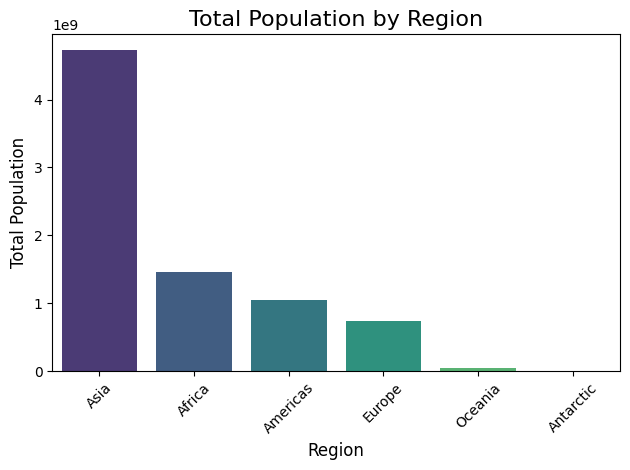

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
# Prepare data: region vs total population
sum_pop = df.groupby('region')['population'].sum().sort_values(ascending = False).reset_index()
# Plot
sns.barplot(data=sum_pop ,x = 'region' ,y='population',palette='viridis',hue='region')
plt.title('Total Population by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Population', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations from the Population Bar Chart

- Asia has the highest total population among all regions, with over 4.6 billion people.

## Task 3b — Which country has the largest area?
* find the country with the **largest area** using `.idxmax()` on the `area` column.  
* display both the **country name** and its **area**.

In [11]:
# Which country has the largest area?
large_area = df.loc[df['area'].idxmax()]
print("country With largest area:",large_area['name'])
print("-"*50)
print(f"{large_area['name']} : Total Length of Area : ",large_area['area'])

country With largest area: Russia
--------------------------------------------------
Russia : Total Length of Area :  17098246.0


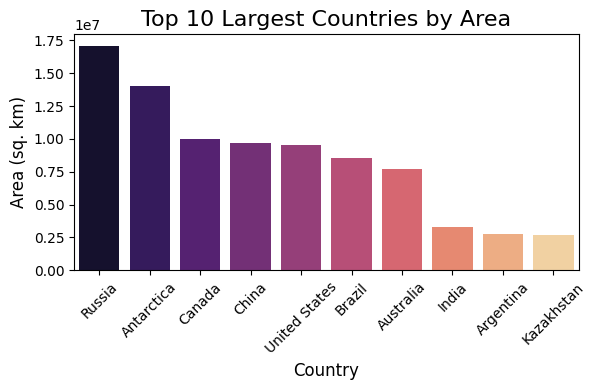

In [38]:
# Sort countries by area descending and take top 10
top_countries_area = df.sort_values(by='area', ascending=False).head(10)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x='name', y='area', data=top_countries_area, palette='magma' , hue = 'name')

plt.title('Top 10 Largest Countries by Area', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Area (sq. km)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations from the Area Bar Chart

- Russia is by far the largest country in the world, followed by Antarctica ,Canada, China, and the United States.